In [ ]:
# authors
# Nguyen Van A, ...

# Submission: SimpleExponentialSmoothing from SES.py (inlined in prediction cell; no pip installs).


In [2]:
# warning:
# only custmoze the 3-4-5 blocks

In [1]:
# library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# input your data here
home = r'./sample_data'
COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

stk = 's1'
A = np.load(f"{home}/{stk}.npy", allow_pickle=True)
P, V = A[:, 2], A[:, 6]

In [ ]:
# customize your prediction - generated from SES.py (do not edit here; edit SES.py and re-run make submit)

import numpy as np


class Predictor:
    """Base interface: same signature as ``prediction``."""

    def predict(self, P: np.ndarray, V: np.ndarray, h: int = 20) -> np.ndarray:
        raise NotImplementedError


class SimpleExponentialSmoothing(Predictor):
    """
    Causal SES on one-period returns r_i = P[i]/P[i-1] - 1.

    - ``Q[0]`` is 0 (no prior return), matching ``target``'s first element.
    - For ``i >= 1``, after observing r_i, the smoothed level s_i is updated and
      ``Q[i] = s_i`` is used as the one-step-ahead forecast of the *next* return
      (consistent with ``main._eval_series`` pairing).

    ``V`` is unused. ``h`` is ignored (kept for a common ``predict`` signature);
    use a subclass or wrapper if you need an ``h``-based warm-up.
    """

    def __init__(self, alpha: float = 0.3) -> None:
        super().__init__()
        if not (0.0 < float(alpha) <= 1.0):
            raise ValueError("alpha must satisfy 0 < alpha <= 1")
        self.alpha = float(alpha)

    def predict(self, P: np.ndarray, V: np.ndarray, h: int = 20) -> np.ndarray:
        _ = V, h
        P = np.asarray(P, dtype=float)
        n = P.size
        if n == 0:
            return np.array([], dtype=float)
        if np.any(P <= 0):
            raise ValueError("P must be strictly positive")

        Q = np.zeros(n, dtype=float)
        if n == 1:
            return Q

        s = P[1] / P[0] - 1.0
        Q[1] = s
        for i in range(2, n):
            r_i = P[i] / P[i - 1] - 1.0
            s = self.alpha * r_i + (1.0 - self.alpha) * s
            Q[i] = s
        return Q

_ses = SimpleExponentialSmoothing(alpha=0.3)


def prediction(P, V, h=20):
    return _ses.predict(P, V, h)


In [4]:
# customize your prediction
def prediction(P, V, h=20):
    def truncate(u):
        v = u
        if v < -0.07:
            u = -0.07
        elif v > 0.07:
            u = 0.07
        return u
    n, L, Q = len(P), [], []
    for i in range(n):
        s, cnt = P[i], 1
        while (cnt <= h) and (i - cnt >= 0):
            s += P[i - cnt]
            cnt += 1
        L.append(s / cnt)
    for i in range(n):
        tmp = L[i] / P[i] - 1
        tmp = truncate(tmp)
        Q.append(tmp)
    return Q

In [5]:
# keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i -1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1 :], t[1 :]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl == True:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num


	base = 0.011  |  abs = 0.019  |  rel = -0.673



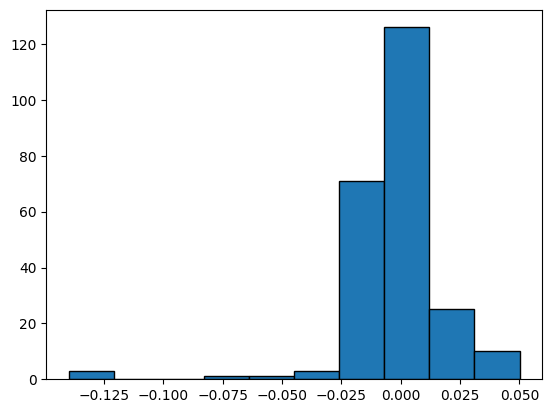

In [6]:
# execute
# Note that score "rel" > 0 shows that there are good signals, "abs" < 0.005 is good signal
p, t = prediction(P, V, 5), target(P, V)
evaluate(p, t, True)